In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import cv2
import ast

from sklearn.model_selection import GroupShuffleSplit

PATH_CLIPS                          = "../Data/Videos/Clips/"
PATH_KEYPOINTS                      = "../Data/Unprocessed/keypoints.csv"
PATH_METRICS                        = "../Data/Unprocessed/metrics.csv"
PATH_ACTIONS_FILTERED               = "../Data/Processed/actions_filtered.csv"

PATH_METADATA                        = "../Data/Processed/metadata.csv"
PATH_TRAIN                           = "../Data/Processed/train.csv"
PATH_TEST                            = "../Data/Processed/test.csv"

WINDOW_SIZE                         = 4
WINDOWS_PER_ACTION                  = 5
NUM_JOINTS                          = 17

FRAME_DROPOUT_P                     = 0.2
TEMPORAL_JITTER_P                   = 0.3
COORDINATE_NOISE_P                  = 0.3
COORDINATE_NOISE_SIGMA              = 0.01
SCALE_TRANSLATE_P                   = 0.3

In [132]:
df_metrics = pd.read_csv(PATH_METRICS)

total_expected_frames = df_metrics["expected"].sum()
total_actual_frames = df_metrics["actual"].sum()
total_coverage = total_actual_frames / total_expected_frames

print(df_metrics[df_metrics["expected"] != df_metrics["actual"]])
print("")

print("Expected frames: ", total_expected_frames)
print("Actual frames:   ", total_actual_frames)
print(f"Coverage:         {total_coverage*100:.2f}%")

    fencer  action_id  start_frame  end_frame  expected  actual   coverage
29    LEFT        170           22         29         8       7  87.500000
41    LEFT        209           22         29         8       7  87.500000
44   RIGHT        219           24         30         7       5  71.428571
65   RIGHT        142           30         37         8       6  75.000000
67   RIGHT        208           29         36         8       6  75.000000
..     ...        ...          ...        ...       ...     ...        ...
430  RIGHT        298           27         44        18      17  94.444444
439  RIGHT        284           16         22         7       6  85.714286
441  RIGHT        280           16         21         6       5  83.333333
446   LEFT        316           28         35         8       7  87.500000
447  RIGHT        317           24         34        11       9  81.818182

[67 rows x 7 columns]

Expected frames:  4247
Actual frames:    4138
Coverage:         97.43%


In [133]:
df_keypoints = pd.read_csv(PATH_KEYPOINTS)

df_keypoints["box"] = df_keypoints["box"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_keypoints["keypoints"] = df_keypoints["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

In [134]:
df_filtered = pd.read_csv(PATH_ACTIONS_FILTERED)

df_merged = df_keypoints.merge(df_filtered, on=["file", "fencer"], how="left")
df_merged = df_merged[
    (df_merged["frame"] >= df_merged["start_frame"]) &
    (df_merged["frame"] <= df_merged["end_frame"])
]

df_merged = df_merged[["file", "fencer", "action_id", "action", "frame", "start_frame", "end_frame", "box", "confidence", "keypoints"]].reset_index(drop=True)
print(df_merged)

               file fencer  action_id        action  frame  start_frame  \
0     1/10_Left.mp4   LEFT          0  ATTACK_LUNGE     23           23   
1     1/10_Left.mp4   LEFT          0  ATTACK_LUNGE     24           23   
2     1/10_Left.mp4   LEFT          0  ATTACK_LUNGE     25           23   
3     1/10_Left.mp4   LEFT          0  ATTACK_LUNGE     26           23   
4     1/10_Left.mp4  RIGHT          1  ATTACK_LUNGE     21           21   
...             ...    ...        ...           ...    ...          ...   
4202   6/9_Left.mp4  RIGHT        468  ATTACK_BASIC     40           38   
4203   6/9_Left.mp4  RIGHT        468  ATTACK_BASIC     41           38   
4204   6/9_Left.mp4  RIGHT        468  ATTACK_BASIC     42           38   
4205   6/9_Left.mp4  RIGHT        468  ATTACK_BASIC     43           38   
4206   6/9_Left.mp4  RIGHT        468  ATTACK_BASIC     44           38   

      end_frame                     box  confidence  \
0            26    (749, 585, 885, 791)    0

In [135]:
gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.8,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df_merged, groups=df_merged['action_id'])
)

df_train = df_merged.iloc[train_idx]
df_test  = df_merged.iloc[test_idx]

In [136]:
action_counts = df_train.groupby("action")["action_id"].nunique().sort_values(ascending=False)
max_count = action_counts.max()

class_weights = max_count / action_counts
weights_dict = class_weights.to_dict()

print(action_counts)
print("")
print(class_weights)

action
ATTACK_LUNGE             169
ATTACK_BASIC             100
DEFENSE_DISTANCE_PULL     54
DEFENSE_POINT_IN_LINE     23
DEFENSE_PARRY             17
ATTACK_FLUNGE              9
Name: action_id, dtype: int64

action
ATTACK_LUNGE              1.000000
ATTACK_BASIC              1.690000
DEFENSE_DISTANCE_PULL     3.129630
DEFENSE_POINT_IN_LINE     7.347826
DEFENSE_PARRY             9.941176
ATTACK_FLUNGE            18.777778
Name: action_id, dtype: float64


In [137]:
def create_action_windows(df, window_size=4, num_windows=4, class_weights=None, random_state=42):
    rng = np.random.default_rng(random_state)
    window_rows = []
    window_counter = 0

    # Sort for safety
    df = df.sort_values(["action_id", "frame"]).reset_index(drop=True)

    for _, group in df.groupby(["action_id"]):
        action = group["action"].iloc[0]

        # Determine number of windows for this action
        weight = class_weights.get(action, 1.0) if class_weights else 1.0
        windows_per_action = max(1, int(round(num_windows * weight)))

        frames = group["frame"].values
        max_start = len(frames) - window_size
        if max_start < 0:
            continue  # action too short for a single window

        start_indices = rng.choice(
            np.arange(0, max_start + 1),
            size=windows_per_action,
            replace=False if windows_per_action <= max_start + 1 else True
        )

        for start in start_indices:
            window_counter += 1
            window_id = window_counter

            window_slice = group.iloc[start:start + window_size].copy()
            window_slice["window_id"] = window_id
            window_rows.append(window_slice)

    return pd.concat(window_rows, ignore_index=True)

In [138]:
df_train_windowed = create_action_windows(df_train, window_size=WINDOW_SIZE, num_windows=WINDOWS_PER_ACTION) # Class weights unnecessary for now
df_test_windowed  = create_action_windows(df_test, window_size=WINDOW_SIZE, num_windows=WINDOWS_PER_ACTION)

train_counts = df_train_windowed.groupby("action")["window_id"].nunique().sort_values(ascending=False)
test_counts  = df_test_windowed.groupby("action")["window_id"].nunique().sort_values(ascending=False)

print(train_counts)
print("")
print(test_counts)

print("")
print("Number of training action snippets: ", df_train_windowed["window_id"].nunique())
print("Number of testing action snippets:  ", df_test_windowed["window_id"].nunique())

action
ATTACK_LUNGE             845
ATTACK_BASIC             500
DEFENSE_DISTANCE_PULL    270
DEFENSE_POINT_IN_LINE    115
DEFENSE_PARRY             85
ATTACK_FLUNGE             45
Name: window_id, dtype: int64

action
ATTACK_LUNGE             210
ATTACK_BASIC             135
DEFENSE_DISTANCE_PULL     55
DEFENSE_POINT_IN_LINE     40
DEFENSE_PARRY             25
ATTACK_FLUNGE              5
Name: window_id, dtype: int64

Number of training action snippets:  1860
Number of testing action snippets:   470


## START UNUSED SECTION

In [139]:
def frame_dropout(kpts, conf, p=0.2, max_frames=2):
    kpts = np.array(kpts, dtype=np.float32)
    conf = np.array(conf, dtype=np.float32)

    T = kpts.shape[0]

    if np.random.rand() > p:
        return kpts, conf

    n_drop = np.random.randint(1, max_frames + 1)
    drop_frames = np.random.choice(T, size=n_drop, replace=False)

    kpts[drop_frames, :, :] = 0.0
    conf[drop_frames, :] = 0.0

    return kpts, conf


def temporal_jitter(kpts, conf=None, p=0.3, max_shift=1):
    kpts = np.array(kpts, dtype=np.float32)
    if conf is not None:
        conf = np.array(conf, dtype=np.float32)

    T = kpts.shape[0]

    if np.random.rand() > p:
        return kpts, conf

    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift == 0:
        return kpts, conf

    kpts_new = np.zeros_like(kpts)
    if conf is not None:
        conf_new = np.zeros_like(conf)
    else:
        conf_new = None

    if shift > 0:
        kpts_new[shift:] = kpts[:-shift]
        if conf is not None:
            conf_new[shift:] = conf[:-shift]
    else:
        kpts_new[:shift] = kpts[-shift:]
        if conf is not None:
            conf_new[:shift] = conf[-shift:]

    return kpts_new, conf_new


def coordinate_noise(kpts, conf=None, p=0.3, sigma=0.01):
    kpts = np.array(kpts, dtype=np.float32)
    if conf is not None:
        conf = np.array(conf, dtype=np.float32)

    if np.random.rand() > p:
        return kpts, conf

    noise = np.random.normal(0, sigma, size=kpts.shape)
    if conf is not None:
        weight = (1.0 - conf)[..., None]  # lower confidence → more noise
        kpts = kpts + noise * weight
    else:
        kpts = kpts + noise

    return kpts, conf


def scale_and_translate(kpts, conf=None, p=0.3, scale_range=(0.9, 1.1), translate_range=0.05):
    kpts = np.array(kpts, dtype=np.float32)
    if conf is not None:
        conf = np.array(conf, dtype=np.float32)

    if np.random.rand() > p:
        return kpts, conf

    scale = np.random.uniform(*scale_range)
    tx = np.random.uniform(-translate_range, translate_range)
    ty = np.random.uniform(-translate_range, translate_range)

    kpts = kpts * scale
    kpts[..., 0] += tx
    kpts[..., 1] += ty

    return kpts, conf


def augment_dataframe(
    df,
    frame_dropout_p=0.2,
    temporal_jitter_p=0.3,
    coordinate_noise_p=0.3,
    coordinate_noise_sigma=0.01,
    scale_translate_p=0.3
):
    df = df.sort_values(["window_id", "frame"]).reset_index(drop=True)
    rows_out = []

    for _, group in df.groupby("window_id"):
        group = group.reset_index(drop=True)

        # Convert lists → arrays
        kpts_list = []
        for k in group["keypoints"]:
            # Handle NaN or empty
            if k is None or (isinstance(k, float) and np.isnan(k)) or len(k) == 0:
                k = np.zeros((17, 2), dtype=np.float32)
            else:
                k = np.array(k, dtype=np.float32)
                if k.shape[0] != 17:
                    pad = np.zeros((17 - k.shape[0], 2), dtype=np.float32)
                    k = np.vstack([k, pad])

            kpts_list.append(k)

        kpts = np.stack(kpts_list)  # (T, 17, 2)
        conf = np.array([[c]*kpts.shape[1] for c in group["confidence"].values], dtype=np.float32)  # (T, J)

        # Apply augmentations
        kpts, conf = frame_dropout(kpts, conf, p=frame_dropout_p)
        kpts, conf = temporal_jitter(kpts, conf, p=temporal_jitter_p)
        kpts, conf = coordinate_noise(kpts, conf, p=coordinate_noise_p, sigma=coordinate_noise_sigma)
        kpts, conf = scale_and_translate(kpts, conf, p=scale_translate_p)

        # Write back frame-wise
        for t, (_, row) in enumerate(group.iterrows()):
            row_dict = row.to_dict()
            row_dict["keypoints"] = kpts[t].tolist()
            row_dict["confidence"] = float(conf[t].mean())
            rows_out.append(row_dict)

    return pd.DataFrame(rows_out)

In [140]:
df_augmented = augment_dataframe(df_train_windowed,
    frame_dropout_p=FRAME_DROPOUT_P,
    temporal_jitter_p=TEMPORAL_JITTER_P,
    coordinate_noise_p=COORDINATE_NOISE_P,
    coordinate_noise_sigma=COORDINATE_NOISE_SIGMA,
    scale_translate_p=SCALE_TRANSLATE_P
)

df_augmented = df_augmented[
    ["file", "fencer", "action_id", "window_id", "action", "frame", "start_frame", "end_frame", "box", "confidence", "keypoints"]
].sort_values(["file", "action_id", "window_id", "frame"]).reset_index(drop=True)

print(df_augmented)

               file fencer  action_id  window_id        action  frame  \
0     1/10_Left.mp4  RIGHT          1          1  ATTACK_LUNGE     21   
1     1/10_Left.mp4  RIGHT          1          1  ATTACK_LUNGE     22   
2     1/10_Left.mp4  RIGHT          1          1  ATTACK_LUNGE     23   
3     1/10_Left.mp4  RIGHT          1          1  ATTACK_LUNGE     24   
4     1/10_Left.mp4  RIGHT          1          2  ATTACK_LUNGE     24   
...             ...    ...        ...        ...           ...    ...   
7435   6/9_Left.mp4  RIGHT        468       1859  ATTACK_BASIC     42   
7436   6/9_Left.mp4  RIGHT        468       1860  ATTACK_BASIC     41   
7437   6/9_Left.mp4  RIGHT        468       1860  ATTACK_BASIC     42   
7438   6/9_Left.mp4  RIGHT        468       1860  ATTACK_BASIC     43   
7439   6/9_Left.mp4  RIGHT        468       1860  ATTACK_BASIC     44   

      start_frame  end_frame                     box  confidence  \
0              21         27  (1067, 574, 1219, 788)   

In [141]:
def plot_skeleton(frame, keypoints, color=(0,1,0), alpha=0.8):
    edges = [
        (0, 1), (1, 3),
        (3, 5), (1, 2),
        (0, 2), (2, 4),
        (4, 6),
        (5, 7), (7, 9),     # left arm
        (6, 8), (8, 10),    # right arm
        (5, 6),             # shoulders
        (11, 12),           # hips
        (5, 11), (6, 12),   # torso
        (11, 13), (13, 15), # left leg
        (12, 14), (14, 16)  # right leg
    ]

    for (i,j) in edges:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        plt.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=2)
    keypoints = np.array(keypoints)
    plt.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)

def draw_random_window(df_windows):
    window_id = random.choice(df_windows["window_id"].unique())
    window_df = df_windows[df_windows["window_id"] == window_id].sort_values("frame")

    video_file = window_df["file"].iloc[0]
    video_path = f"{PATH_CLIPS}/{video_file}"
    cap = cv2.VideoCapture(video_path)

    frame_indices = window_df["frame"].values
    keypoints_list = window_df["keypoints"].values
    fencer_list = window_df["fencer"].values
    action = window_df["action"].iloc[0]

    n_frames = len(frame_indices)
    ncols = 4
    nrows = math.ceil(n_frames / ncols)

    plt.figure(figsize=(4 * ncols, 4 * nrows))

    for i, (fid, kpts, fencer) in enumerate(zip(frame_indices, keypoints_list, fencer_list)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
        ret, frame = cap.read()
        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(frame_rgb)
        ax.axis("off")
        ax.set_title(f"{fencer} - Frame {fid}")

        # Convert keypoints to numpy array if needed
        if isinstance(kpts, str):
            kpts = np.array(eval(kpts))
        elif isinstance(kpts, list):
            kpts = np.array(kpts)

        if kpts is not None and not (isinstance(kpts, float) and np.isnan(kpts)):
            plot_skeleton(ax, kpts, color=(0,1,0) if fencer=="LEFT" else (1,0,0))

    plt.suptitle(f"Action: {action}", fontsize=16)
    plt.tight_layout()
    plt.show()
    cap.release()

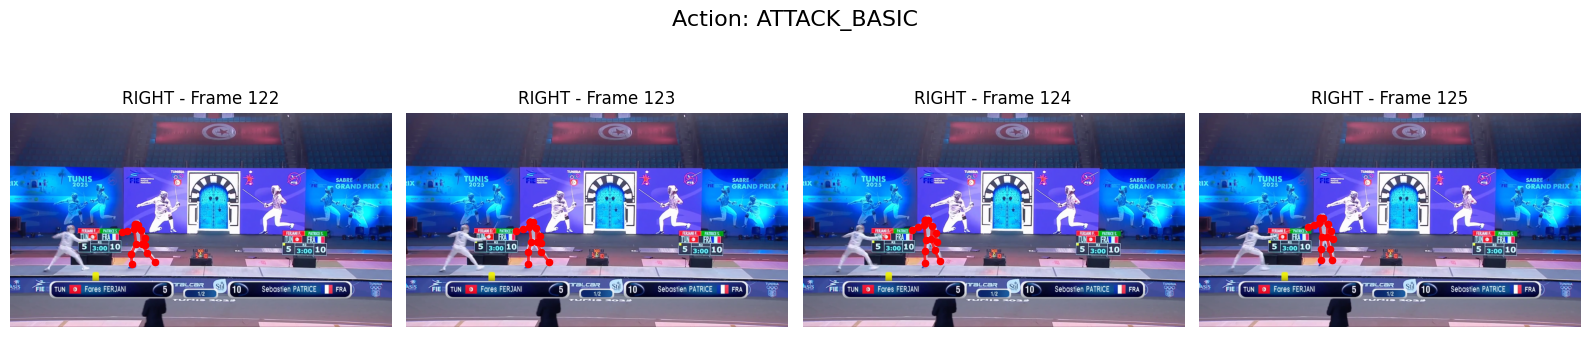

In [142]:
draw_random_window(df_augmented)

## END UNUSED SECTION

In [143]:
def explode_keypoints(df):
    # Expand each tuple into separate x,y columns
    exploded = df["keypoints"].apply(
        lambda kp: [coord for point in kp for coord in point]
    )

    # Create column names: x0, y0, x1, y1, ...
    num_points = len(df.iloc[0]["keypoints"])
    cols = [f"x{i}" for i in range(num_points)] + [f"y{i}" for i in range(num_points)]
    
    new_df = pd.DataFrame(exploded.tolist(), columns=cols)
    return pd.concat([df.drop(columns=["keypoints"]), new_df], axis=1)

In [144]:
df_metadata_train = df_augmented[["file", "fencer", "action_id", "window_id", "action", "frame", "start_frame", "end_frame", "box"]]
df_metadata_test = df_test_windowed[["file", "fencer", "action_id", "window_id", "action", "frame", "start_frame", "end_frame", "box"]]

df_metadata = pd.concat([df_metadata_train, df_metadata_test], ignore_index=True)
df_metadata.sort_values(["action_id", "window_id", "frame"], inplace=True)

df_train_data = df_train_windowed[["window_id", "frame", "action", "confidence", "keypoints"]].copy()
df_test_data = df_test_windowed[["window_id", "frame", "action", "confidence", "keypoints"]].copy()

df_train_data.sort_values(["window_id"], inplace=True)
df_test_data.sort_values(["window_id"], inplace=True)

df_train_data = explode_keypoints(df_train_data)
df_test_data = explode_keypoints(df_test_data)

df_train_data.to_csv(PATH_TRAIN, index=False)
df_test_data.to_csv(PATH_TEST, index=False)
df_metadata.to_csv(PATH_METADATA, index=False)